# 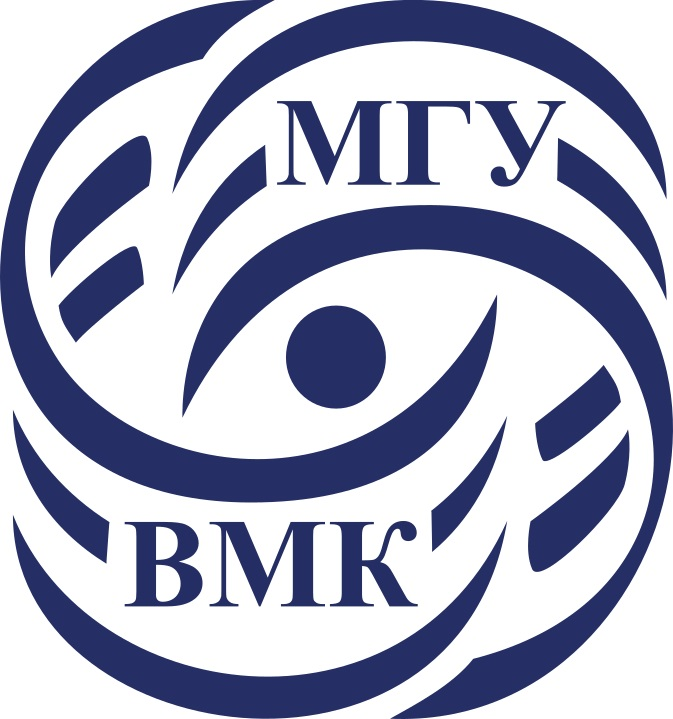

# Машинное обучение. ВМК МГУ

# Практическое задание 3: Линейные модели: регрессия

## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







Цель данного задания:

* Узнать, что такое переобучение и как с ним бороться в линейных моделях;
* Понять, чем отличаются разные регуляризаторы;
* Научиться решать задачу регрессии линейными моделями.
-------
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: 7 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [4]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1109      0 --:--:-- --:--:-- --:--:--  1111


Проверим версию библиотеки:

In [5]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Линейная регрессия и регуляризация

Напомним, что линейная регрессия — это модель следующего вида: $$a(x) = \langle w, x \rangle + b$$ где $w \in \mathbb{R}^d$, $b \in \mathbb{R}$. Обучить линейную регрессию — значит найти $w$ и $b$.

В модели линейной регрессии с $l_2$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^M (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \frac{\alpha}{2} \cdot \left( w_1^2 + \dots + w_n^2 \right) \rightarrow \min_{w_1, \dots, w_n, b}$

В модели линейной регрессии с $l_1$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^M (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \alpha \cdot \left( |w_1| + \dots + |w_n| \right) \rightarrow \min_{w_1, \dots, w_n, b}$

### <font color='DarkOrange'>**Задание 1 [1 балл]**</font>

Почему при обучении линейных моделей, коэффициент $b$ не регуляризуется? Дайте ответ с опорой на лекции. Возможно вам также поможет картика из базовой части

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Потому что регуляризация борется с мультиколлинеарностью и устойчивостью оценок, то есть с зависимостями между признаками, b же является глобальной переменной, которое в общем случае естественно равно среднему всех таргетов, то есть это свободный член или же сдвиг, и он не должен быть частью вариации, то есть по-хорошему это несмещённаяя оценка матожа и вокруг неё мы строим нашу линейную аппроксимацию и вот вся вариация должна быть в признаках, при регуляризации с учётом b мы бы по непонятным причинам b сдвигали и не решали бы проблему с зависимостью между признаками

-----
<font color="white" style="opacity:0.2025"></font>

Рассмотрим модель линейной регрессии с $l_2$ регуляризацией. В sklearn эта модель реализована посредством класса Ridge. В нём есть методы fit и predict. Первый принимает на вход обучающую выборку и вектор целевых переменных и обучает модель, второй, будучи вызванным после обучения модели, возвращает предсказание на выборке.

Сгенерируем случайные данные. Пусть $x$ будет обычным числом из равномерного распределения, а $𝑦=0.5 \cdot x + 0.1$ &mdash; целевая переменная. При этом наблюдаем мы $\overline{y} = y + \varepsilon,~\varepsilon \sim N(0, 0.01)$. Добавим в данные к переменной $x$ её же умноженную на $3$. То есть, теперь у нас два признака $x_1$ и $x_2 = 3 \cdot x_1$.

Поскольку  $y = c \cdot 0.5 \cdot x_1 + \frac{1 - c}{6} \cdot x_2 + 0.1$, где $c$ любое сколь угодно большое вещественное число. То, как мы могли убедиться в базовой части, без регуляризации есть риск выучить очень большие веса.

Посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [7]:
from sklearn.linear_model import Ridge

In [8]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = X * 0.5 + 0.1 + np.random.randn(100) * 0.1

X3 = np.hstack((X[:, None], 3 * X[:, None]))
Y3 = X3[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

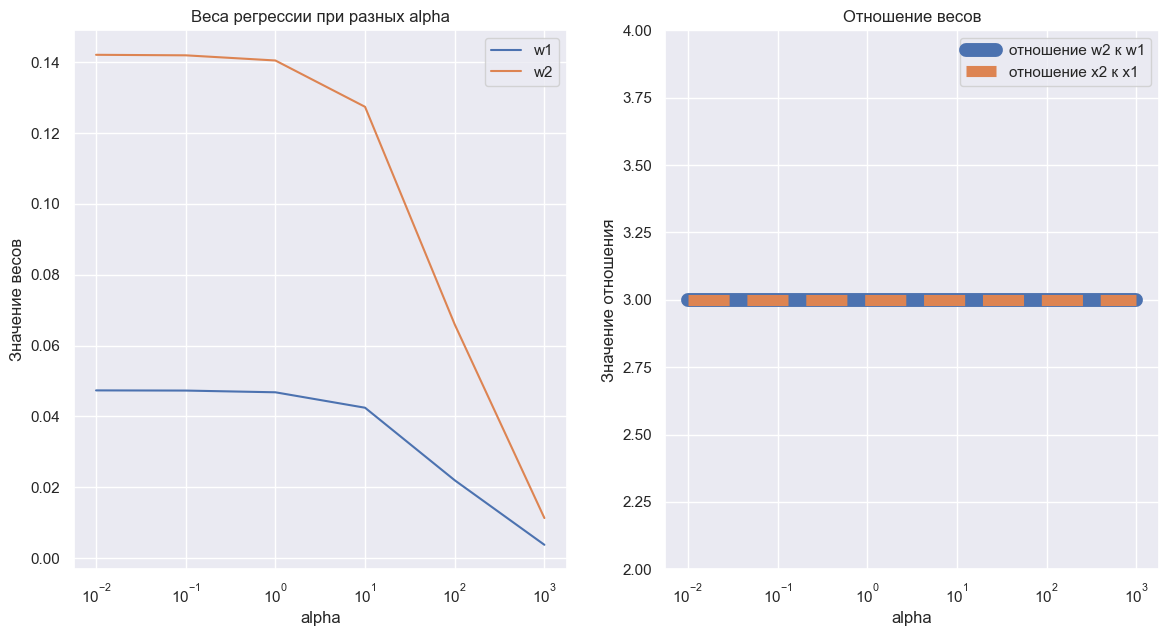

In [9]:
w1 = []
w2 = []

alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X3, Y3)
    w1.append(reg.coef_[0])
    w2.append(reg.coef_[1])

w1 = np.array(w1)
w2 = np.array(w2)

fig, axs = plt.subplots(figsize=(14, 7), ncols=2)
axs[0].plot(alphas, w1, label="w1")
axs[0].plot(alphas, w2, label="w2")
axs[0].set_xscale("log")
axs[0].set_title("Веса регрессии при разных alpha")
axs[0].set_xlabel("alpha")
axs[0].set_ylabel("Значение весов")
axs[0].legend()
axs[1].plot(alphas, w2 / w1, label="отношение w2 к w1", linewidth=10)
axs[1].plot([0.01, 1000], [3, 3], label="отношение x2 к x1", linestyle="--", linewidth=8)
axs[1].set_xscale("log")
axs[1].set_ylim(2,4)
axs[1].set_xlabel("alpha")
axs[1].set_ylabel("Значение отношения")
axs[1].set_title("Отношение весов")
axs[1].legend()
plt.show()

### <font color='DarkOrange'>**Задание 2 [2 баллa]**</font>

Как думаете, почему отношение между весами постоянно? (подсказка, необходимо выписать функцию потерь и посчитать производные по весам)

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Производные по весам
$$\frac{\partial L}{\partial w1} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + w_2 \cdot x_{i2} + b - y_i) + \alpha w_1$$
$$\frac{\partial L}{\partial w2} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i2} (w_1 \cdot x_{i1} + w_2 \cdot x_{i2} + b - y_i) + \alpha w_2$$

Заметим, что

$$\frac{\partial L}{\partial w1} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i) + \alpha w_1$$
$$\frac{\partial L}{\partial w2} = \frac{1}{M} \cdot ∑_{i=1}^M 6x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i) + \alpha w_2$$

И так как мы минимизируем
$$\frac{\partial L}{\partial w1} = 0, \frac{\partial L}{\partial w2} = 0$$

Откуда
$$\alpha w_1 = -\frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i)$$
$$\alpha w_2 = -\frac{1}{M} \cdot ∑_{i=1}^M 6x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i)$$

Ну и
$$\frac{w_2}{w_1} = 3$$


-----
<font color="white" style="opacity:0.2025"></font>

Заметим, что при $l_2$ регуляризации в данном примере веса получились пропорциональны значениям признаков. При этом, мы знаем, что оба признака взаимно однозначны, и прогноз можно делать только по одному из них. Для этого придумана $l_1$ регуляризация. В билиотеке sklearn линейная регрессия с $l_1$ регуляризацией реализована в классе Lasso

### <font color='DarkOrange'>**Задание 3 [2 баллa]**</font>

Почему в нашем примере $l_1$ регуляризация приведёт к разреживанию весов? (подсказка, нужно опять подсчитать производную, но обратите внимание на дифференцируемость модуля).

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Опять таки, производные по весам
$$\frac{\partial L}{\partial w1} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + w_2 \cdot x_{i2} + b - y_i) + \alpha \cdot sgn(w_1)$$
$$\frac{\partial L}{\partial w2} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i2} (w_1 \cdot x_{i1} + w_2 \cdot x_{i2} + b - y_i) + \alpha \cdot sgn(w_2)$$

Ну и вновь заметим, что

$$\frac{\partial L}{\partial w1} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i) + \alpha \cdot sgn(w_1)$$
$$\frac{\partial L}{\partial w2} = \frac{1}{M} \cdot ∑_{i=1}^M 6x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i) + \alpha \cdot sgn(w_2)$$

И в очередной раз так как мы минимизируем
$$\frac{\partial L}{\partial w1} = 0, \frac{\partial L}{\partial w2} = 0$$

Откуда
$$\alpha \cdot sgn(w_1) = -\frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i)$$
$$\alpha \cdot sgn(w_2) = -\frac{1}{M} \cdot ∑_{i=1}^M 6x_{i1} (w_1 \cdot x_{i1} + 3w_2 \cdot x_{i1} + b - y_i)$$

Ну и
$$sgn(w_2) = 3 \cdot sgn(w_1)$$

Но это возможно только если $sgn(w_2) = sgn(w1) = 0$, т.к. $sgn(x) \in \{-1,0,1\}$, ну и учтём, что существует шум и модель лишь приближение, поэтому скорее всего в ноль уйдёт только один из весов


-----

Добавим $l_1$ регуляризацию и посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [10]:
from sklearn.linear_model import Lasso

In [11]:
reg = Lasso(alpha=1., max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 1.")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.1, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.1")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.01, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.01")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.0001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.0001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.00001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.00001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

Веса, при alpha = 1.
w1: 0.0 	w2: 0.0

Веса, при alpha = 0.1
w1: 0.0 	w2: 0.029684463509327023

Веса, при alpha = 0.01
w1: 0.0 	w2: 0.14506160917248503

Веса, при alpha = 0.001
w1: 0.0 	w2: 0.15659932373880084

Веса, при alpha = 0.0001
w1: 0.0 	w2: 0.15775309519543249

Веса, при alpha = 0.00001
w1: 0.396687319914549 	w2: 0.025639365702912652



### <font color='DarkOrange'>**Задание 4 [2 баллa]**</font>

Почему в итоге при $\alpha = 0.00001$ получились веса не равные нулю?

<font color='LightSteelBlue'>**Подсказка**</font>

 Обратите внимание на то, каким странным получился вес $w_2$

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

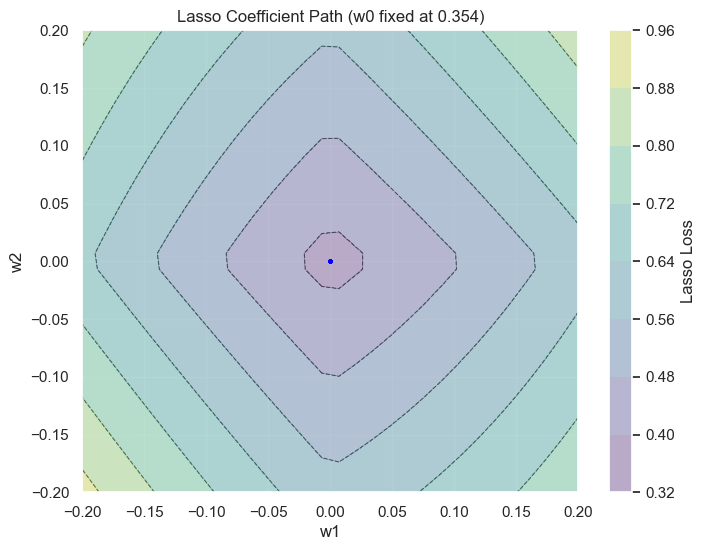

Итоговые коэффициенты:
b (intercept): 0.35428030300407953
w1 (x1): 0.0
w2 (x2): 0.0


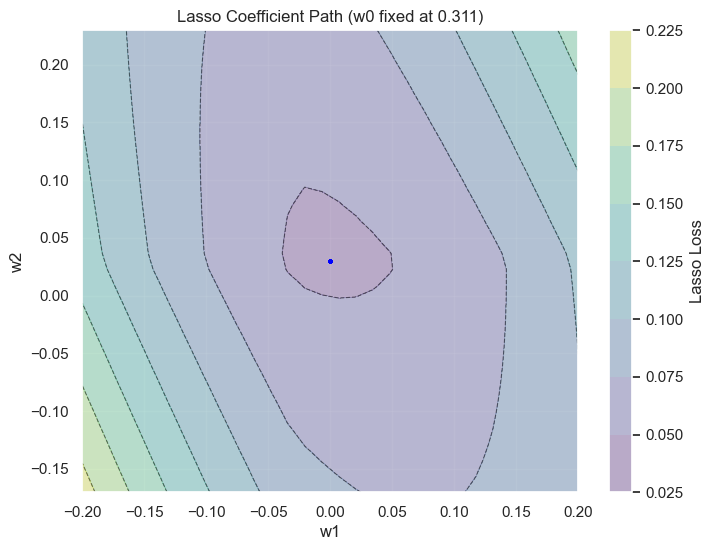

Итоговые коэффициенты:
b (intercept): 0.3110112261685776
w1 (x1): 0.0
w2 (x2): 0.029684463509327023


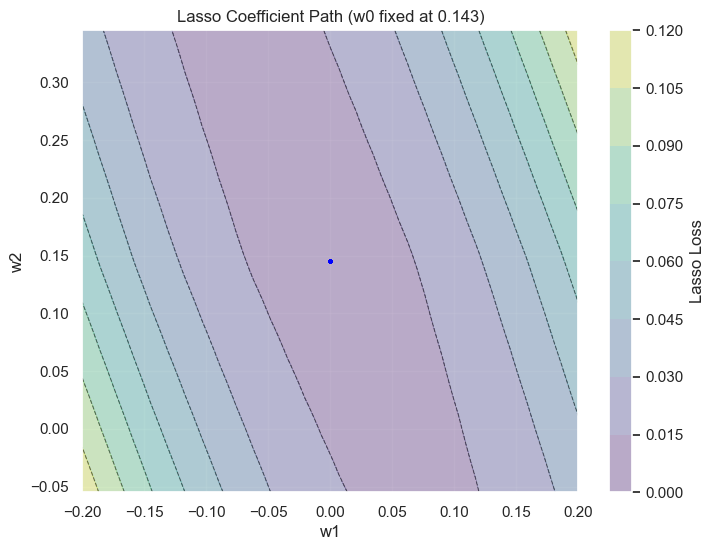

Итоговые коэффициенты:
b (intercept): 0.14283360088687155
w1 (x1): 0.0
w2 (x2): 0.14506160917248503


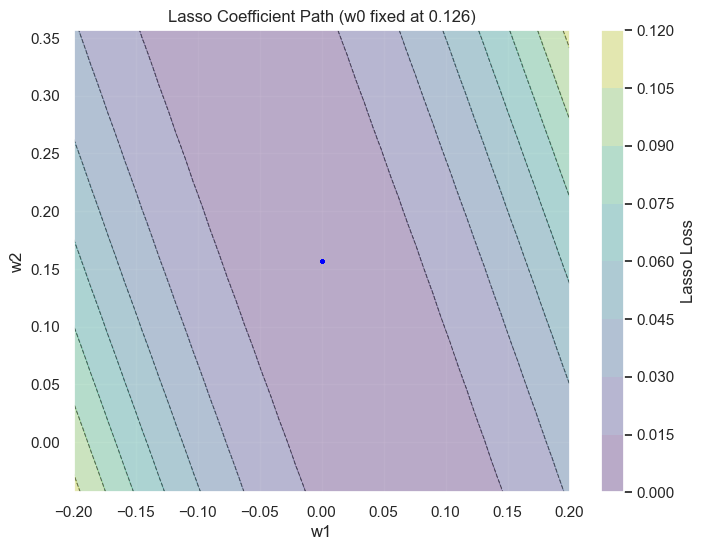

Итоговые коэффициенты:
b (intercept): 0.12601583835870095
w1 (x1): 0.0
w2 (x2): 0.15659932373880084


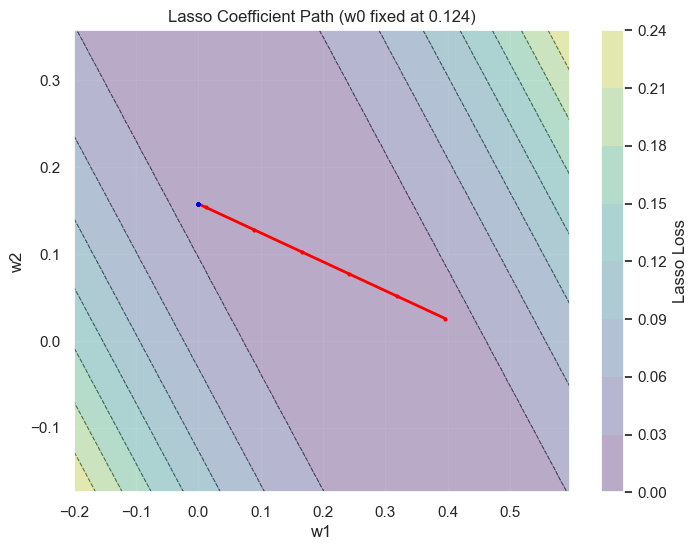

Итоговые коэффициенты:
b (intercept): 0.1243340621058838
w1 (x1): 0.0
w2 (x2): 0.15775309519543249


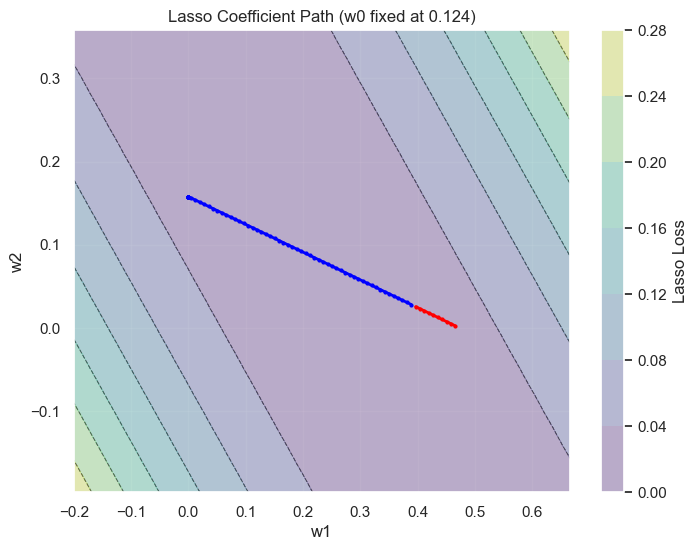

Итоговые коэффициенты:
b (intercept): 0.12416588448060198
w1 (x1): 0.0
w2 (x2): 0.15786847234109572


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

def lasso_loss(w_temp, preds, y):
    return 0.5 * np.mean((y - preds) ** 2) + alpha * np.sum(np.abs(w_temp))

def plot_w1_w2_trace(X, y, weights, max_iter_orig):
    w0_fixed = weights[-1, 0] if len(weights) > 0 else 0.0
    
    w1_vals = np.linspace(weights[:, 1].min() - 0.2, weights[:, 1].max() + 0.2, 30)
    w2_vals = np.linspace(weights[:, 2].min() - 0.2, weights[:, 2].max() + 0.2, 30)
    
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    vals = np.zeros_like(W1)
    
    for i in range(len(w1_vals)):
        for j in range(len(w2_vals)):
            w_temp = np.array([w0_fixed, w1_vals[i], w2_vals[j]])
            preds = w_temp[0] + X @ w_temp[1:]
            vals[i, j] = lasso_loss(w_temp, preds, y)
    
    plt.figure(figsize=(8, 6))
    plt.contour(W1, W2, vals, colors='black', linestyles='dashed', linewidths=0.8, alpha=0.5)
    plt.contourf(W1, W2, vals, alpha=0.3, cmap='viridis')
    
    plt.plot(weights[:max_iter_orig, 1], weights[:max_iter_orig, 2], marker='.', color='red', linewidth=2, markersize=4)
    plt.plot(weights[max_iter_orig:, 1], weights[max_iter_orig:, 2], marker='.', color='blue', linewidth=2, markersize=4)
    
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title(f'Lasso Coefficient Path (w0 fixed at {w0_fixed:.3f})')
    plt.colorbar(label='Lasso Loss')
    plt.grid(True, alpha=0.3)


def generate_lasso_iterations_simplified(X, y, alpha=0.00001, tol=1e-4, max_total_iter=50, step=1, max_iter_orig=1000):
    weights_history = []
    
    for iter_num in range(step, max_total_iter + 1, step):
        model = Lasso(alpha=alpha, max_iter=iter_num, tol=tol)
        model.fit(X, y)
        weights = [model.intercept_] + list(model.coef_)
        weights_history.append(weights)
    
    plot_w1_w2_trace(X, y, np.array(weights_history), max_iter_orig // step)
    plt.show()
    
    return np.array(weights_history)

for alpha in 1., 0.1, 0.01, 0.001, 0.0001, 0.00001:
    weights_history = generate_lasso_iterations_simplified(X3, Y3, alpha=alpha, tol=1e-4, max_total_iter=10000, step=100)
    print("Итоговые коэффициенты:")
    print("b (intercept):", weights_history[-1][0])
    print("w1 (x1):", weights_history[-1][1])
    print("w2 (x2):", weights_history[-1][2])


-----

Ну, Lasso &mdash; итерационный метод так-то, и как мы можем видеть, он может долго сходится, в данном случае, в связи с оптимизатором думаю, при уменьшении $\alpha$ количество шагов, необходимых для сходимости начинает расти, и здесь показано вот что на графиках: красным показан путь в пространстве w1, w2, который пройден за исходные 1000 итераций, а синим путь который я добавил (итерировался 10'000), и вплоть до $\alpha = 10^{-4}$ у нас всё успевало сойтись, а вот как мы видим при $\alpha = 10^{-5}$ модель продолжала обучаться ещё приличное количество шагов, а следовательно нам попросту не хватило итераций. В этом можно убедиться, заметив, что я вывел коэффициенты, полученные после 10'000 шагов, там w1 вновь занулился. Причём как мы видим, он сошёлся примерно туда же, куда и при $\alpha = 10^{-4}$ но шёл туда значительно дольше. Думаю так

В предущих блоках мы использовали модельные примеры, в которых $y$ зависел от $x$ линейно. Но так бывает далеко не всегда.

### <font color='DarkOrange'>**Задание 5 [1 баллa]**</font>

 Придумайте, сгенерируйте и визуализируйте пример, в котором линейная регрессия будет плохо классифицировать данные.

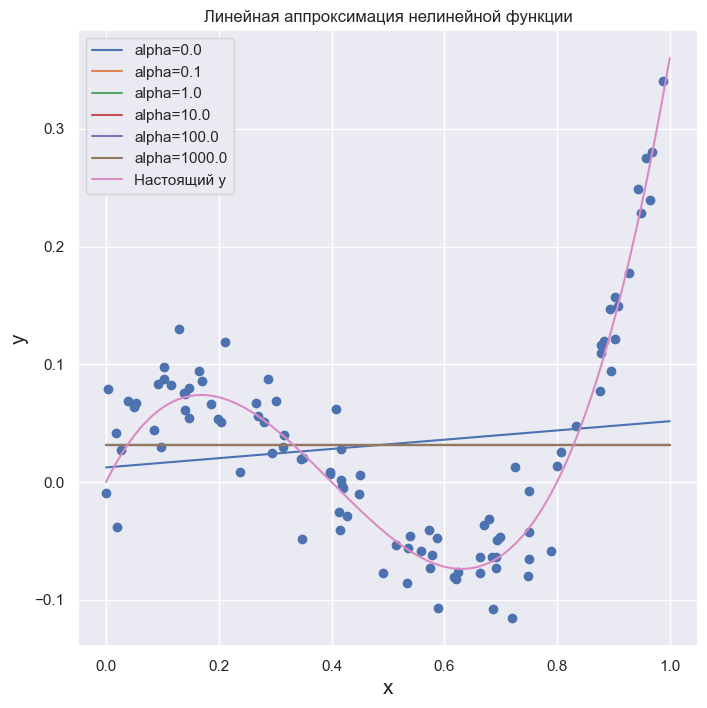

In [61]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = 3 * (X - 0) * (X - 0.4) * (X - 0.8) + np.random.randn(100) * 0.03

fig = plt.figure(figsize=(8, 8))
plt.scatter(X, Y)
plt.title("Обучающая выборка зависимости y от x", size=15)
plt.xlabel("x", size=15)
plt.ylabel(r'$\overline{y}$', size=15)

x_axis = np.linspace(0, 1, 200)
alphas = [0.0, 0.1, 1.0, 10.0, 100.0, 1000.0]

axs, = fig.get_axes()

for alpha in alphas:
    reg = Lasso(alpha=alpha, max_iter=1000, tol=1e-4)
    reg.fit(X[:, None], Y)
    pred = reg.predict(x_axis[:, None])
    axs.plot(x_axis, pred, label="alpha=" + str(alpha))

# Истинное распределение
axs.plot(x_axis[:, None], 3 * x_axis * (x_axis - 0.4) * (x_axis - 0.8), label="Настоящий y")

axs.legend()
axs.set_xlabel("x", size=15)
axs.set_ylabel("y", size=15)
axs.set_title("Линейная аппроксимация нелинейной функции")
plt.show()



### <font color='DarkOrange'>**Задание 6 [2 баллa]**</font>

Приведите искусственный пример (можно даже очень неправдоподобный), когда линейная регрессия с $l_2$ регуляризацией гарантированно занулит какой-нибудь признак? Покажите (теоретически или программно), что признак действительно зануляется


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
np.random.seed(42)

n = 100
x1 = np.random.randn(n)
x2 = np.repeat(0., n)
y = 5 * x1

X = np.column_stack([x1, x2])
ridge = Ridge(alpha=0.7)
ridge.fit(X, y)
print("Коэффициенты:", ridge.coef_)

Коэффициенты: [4.95749963 0.        ]


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

$$L=\frac{1}{N} \cdot \sum^{N}_{i=1}(\mathbf{w}^{T}\mathbf{x}+b-y_i)^2+\frac{\alpha}{2}\cdot\mathbf{w}^{T}\mathbf{w}$$
$$L=\frac{1}{N} \cdot \sum^{N}_{i=1}(w_1x_{1i}+w_2x_{2i}+b-y_i)^2+\frac{\alpha}{2}\cdot(w_1^2+w_2^2)$$

В нашем примере $\mathbf{x_2}=\vec{0}$:
$$L=\frac{1}{N} \cdot \sum^{N}_{i=1}(w_1x_{1i}+b-y_i)^2+\frac{\alpha}{2}\cdot(w_1^2+w_2^2)$$


Тогда производные:
$$\frac{\partial L}{\partial w1} = \frac{1}{M} \cdot ∑_{i=1}^M 2x_{i1} (w_1 \cdot x_{i1} + b - y_i) + \alpha w_1$$
$$\frac{\partial L}{\partial w2} = \alpha w_2$$

И так как мы минимизируем
$$\frac{\partial L}{\partial w1} = 0, \frac{\partial L}{\partial w2} = 0$$

Откуда
$$w_2 = 0$$


**Выводы** В первой части задания по линейным моделям мы должны были узнать:
.

1.   Зачем нужна регуляризация.
2.   Как отбирать значащие признаки.
3.   Когда линейные модели работают хорошо, а когда плохо

-----
<font color="white" style="opacity:0.2025"></font>

Во **второй части** мы будем применять линейные модели для классификации реальных данных, где мы сможем проверить наши выводы, полученные на искуственных примерах. А также убедимся в полезности нормировки и научимся работать с разными видами данных.
